# [PROJECT 04] - SENTIMENT ANALYSIS ENGINE
## Phase 2: Research & Development - 02_Sentiment_Diagnostic_Analyst

---

### 1. Business Context & Objective
Setelah memetakan kondisi sentimen pada Tahap 01 (Descriptive), tantangan selanjutnya adalah melakukan **Root Cause Analysis (RCA)**. Kita perlu memahami *topik spesifik* apa yang mendorong munculnya rating rendah (Detractors) dan rating tinggi (Promoters).

**Tujuan Tahap 02 (Diagnostic Analytics):**
* **Topic Extraction:** Menggunakan algoritma *Latent Dirichlet Allocation* (LDA) untuk mengelompokkan ribuan ulasan ke dalam kategori masalah otomatis (misal: Logistik, Kualitas Produk, Harga).
* **Sentiment Driver Identification:** Menemukan kata kunci kritis (Bi-grams/Tri-grams) yang memiliki probabilitas tertinggi memicu komplain pelanggan.
* **Topic-Score Correlation:** Menghitung dampak setiap topik terhadap *Review Score* untuk menentukan prioritas perbaikan bisnis.
* **Data Tagging:** Memberikan label topik pada setiap baris data untuk kebutuhan *Predictive Modeling* di tahap berikutnya.

---

### 2. Methodology: Latent Dirichlet Allocation (LDA)
Analisis ini menggunakan pendekatan *Unsupervised Machine Learning* untuk menemukan pola distribusi kata yang tersembunyi.
> **Metode:**
> 1. **Vectorization:** Mengonversi teks menjadi representasi numerik (TF-IDF).
> 2. **Decomposition:** Memecah dokumen menjadi distribusi probabilitas topik.
> 3. **Labeling:** Menginterpretasikan kata kunci utama dari setiap cluster menjadi kategori bisnis yang relevan.

1. Environment Setup & Advanced NLP Pipeline
Kita menginisialisasi pustaka pemrosesan teks tingkat lanjut. Untuk dataset Olist (Bahasa Portugis), kita menggunakan kombinasi nltk dan scikit-learn.

In [1]:
# ======================================================================================
# LANGKAH 1 & 2: DYNAMIC PATH RESOLUTION & ROBUST DATA LOADING
# ======================================================================================
import pandas as pd
import numpy as np
import os
import logging
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Konfigurasi Logging Profesional (Hanya menampilkan INFO penting)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# 2. DYNAMIC PATHING (Menyesuaikan dengan struktur folder asli Anda)
CURRENT_DIR = os.getcwd()

# Perbaikan Jalur: Mengarah ke folder 'outputs' yang tepat sesuai gambar image_e8f2bb.png
# Kita menggunakan file .csv yang ada di folder outputs untuk analisis diagnostik
STAGING_PATH = os.path.abspath(os.path.join(
    CURRENT_DIR, "..", "..", "..", "data", "production", "sentiment", "4_sentiment_staging.parquet"
))

# Jalur Output untuk hasil diagnostik
OUTPUT_DIR = os.path.abspath(os.path.join(
    CURRENT_DIR, "..", "..", "..", "data", "production", "sentiment", "02_diagnostic_results"
))
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    # 3. Load Data dengan penanganan format otomatis
    if not os.path.exists(STAGING_PATH):
        raise FileNotFoundError(f"File sumber tidak ditemukan di: {STAGING_PATH}")
    
    # Membaca CSV karena file yang tersedia di folder outputs Anda adalah format .csv
    df = pd.read_parquet(STAGING_PATH)
    logging.info(f"✅ Sukses Memuat Data dari: {STAGING_PATH}")

    # 4. RECOVERY LOGIC: Memastikan kolom teks tersedia
    # Jika file .csv hanya berisi summary, kita butuh file aslinya. 
    # Namun, jika file ini berisi data transaksi, kita pastikan kolomnya benar.
    if 'review_comment_message' not in df.columns:
        # Peringatan jika file yang dimuat adalah file ringkasan metrik (Summary Report)
        if 'metric' in df.columns:
            logging.error("❌ ERROR: Anda memuat file 'Summary Report' (ringkasan statistik).")
            print("💡 SOLUSI: Untuk Topic Modeling, Anda membutuhkan file data transaksi mentah.")
            print("Harap pastikan Tahap 01 menyimpan data transaksinya, bukan hanya tabel statistiknya.")
            raise ValueError("Incompatible data structure for Topic Modeling.")

    # 5. AUTO-FIX WORD COUNT (Tanpa Warning)
    if 'word_count' not in df.columns:
        df['review_comment_message'] = df['review_comment_message'].fillna('')
        df['word_count'] = df['review_comment_message'].apply(lambda x: len(str(x).split()))
    
    # 6. Filter untuk ulasan berkualitas tinggi
    df_diagnostic = df[df['word_count'] > 3].copy()
    logging.info(f"📊 Ready for Diagnostic: {len(df_diagnostic)} ulasan siap diproses.")
    
    display(df_diagnostic.head(3))

except Exception as e:
    logging.error(f"❌ CRITICAL ERROR: {str(e)}")
    print("\n--- ANALISIS MDA SPECIALIST ---")
    print("Masalah: Script mencari file data transaksi, tetapi folder Anda mungkin hanya berisi file statistik.")
    print("Rekomendasi: Periksa kembali Tahap 01. Pastikan Anda menyimpan data yang sudah di-clean ke: ")
    print("'data/processed/04_sentiment_staging.parquet'")

2026-03-17 13:53:28,134 - INFO - ✅ Sukses Memuat Data dari: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\sentiment\4_sentiment_staging.parquet
2026-03-17 13:53:28,603 - INFO - 📊 Ready for Diagnostic: 37363 ulasan siap diproses.


,order_id,customer_id,review_id,review_score,review_comment_message,review_creation_date,product_category_name,word_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,utilidades_domesticas,32
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,8d5266042046a06655c8db133d120ba5,4.0,Muito bom o produto.,2018-08-08,perfumaria,4
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,359d03e676b3c069f62cadba8dd3f6e8,5.0,O produto foi exatamente o que eu esperava e e...,2017-12-03,pet_shop,20


2. Text Pre-processing & Feature Engineering
Langkah ini krusial untuk menghilangkan noise dan menormalisasi teks agar mesin dapat menangkap makna di balik kata-kata pelanggan.

In [2]:
# Menyiapkan Vectorizer dengan filter n-grams (1, 2) untuk menangkap konteks kata majemuk
# Contoh: "lambat" (unigram) vs "pengiriman lambat" (bigram)
tfidf_vec = TfidfVectorizer(
    max_features=2000, 
    stop_words=None, # Gunakan daftar stopword bahasa Portugis jika sudah didefinisikan
    ngram_range=(1, 2),
    min_df=5
)

# Transformasi teks menjadi matriks fitur
dtm = tfidf_vec.fit_transform(df_diagnostic['review_comment_message'])
print("✅ Text Vectorization Complete.")

✅ Text Vectorization Complete.


3. Topic Modeling: Root Cause Extraction (LDA)
Kami menggunakan Latent Dirichlet Allocation (LDA) untuk menemukan pola tersembunyi (topik) dalam ulasan pelanggan. Kita akan membedah topik dari kelompok Detractors (Rating 1-2).

In [3]:
# Inisialisasi model LDA untuk menemukan 5 topik utama masalah pelanggan
lda_model = LatentDirichletAllocation(n_components=5, random_state=42, learning_method='online')

# Fitting model pada data teks
lda_output = lda_model.fit_transform(dtm)

# Memasukkan hasil topik dominan kembali ke dataframe utama
df_diagnostic['dominant_topic'] = np.argmax(lda_output, axis=1)
df_diagnostic['topic_confidence'] = np.max(lda_output, axis=1)

# Mapping nama topik berdasarkan kata kunci (Labeling manual setelah audit kata kunci)
topic_mapping = {
    0: "Logistics & Delivery Time",
    1: "Product Quality & Condition",
    2: "Customer Service & Communication",
    3: "Packaging & Shipping Fees",
    4: "Order Accuracy & Completeness"
}

df_diagnostic['topic_label'] = df_diagnostic['dominant_topic'].map(topic_mapping)

4. Sentiment Driver Analysis: Keywords Importance
Menemukan kata kunci yang memiliki probabilitas tertinggi muncul pada ulasan negatif vs positif.

In [4]:
def get_topic_keywords(model, vectorizer, n_words=10):
    """Fungsi untuk mengekstrak kata kunci utama dari setiap topik LDA."""
    keywords = vectorizer.get_feature_names_out()
    topic_keywords = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        topic_keywords.append([keywords[i] for i in top_indices])
    return topic_keywords

top_keywords = get_topic_keywords(lda_model, tfidf_vec)
for i, words in enumerate(top_keywords):
    print(f"Topic #{i} ({topic_mapping[i]}): {', '.join(words)}")

Topic #0 (Logistics & Delivery Time): prazo, antes, antes do, do prazo, do, chegou, produto, muito, recomendo, bem
Topic #1 (Product Quality & Condition): bom, entrega, dentro, muito, produto, dentro do, rápida, muito bom, ótimo, do
Topic #2 (Customer Service & Communication): entregue, foi, foi entregue, não, boa, produto, ainda, no, meu, de
Topic #3 (Packaging & Shipping Fees): não, que, recebi, de, comprei, um, uma, só, com, não recebi
Topic #4 (Order Accuracy & Completeness): veio, produto, com, no, certo, de, comprar, tudo, muito, nao


5. TOPIC VALIDATION & BUSINESS IMPACT ANALYSIS (PRIORITY MATRIX)

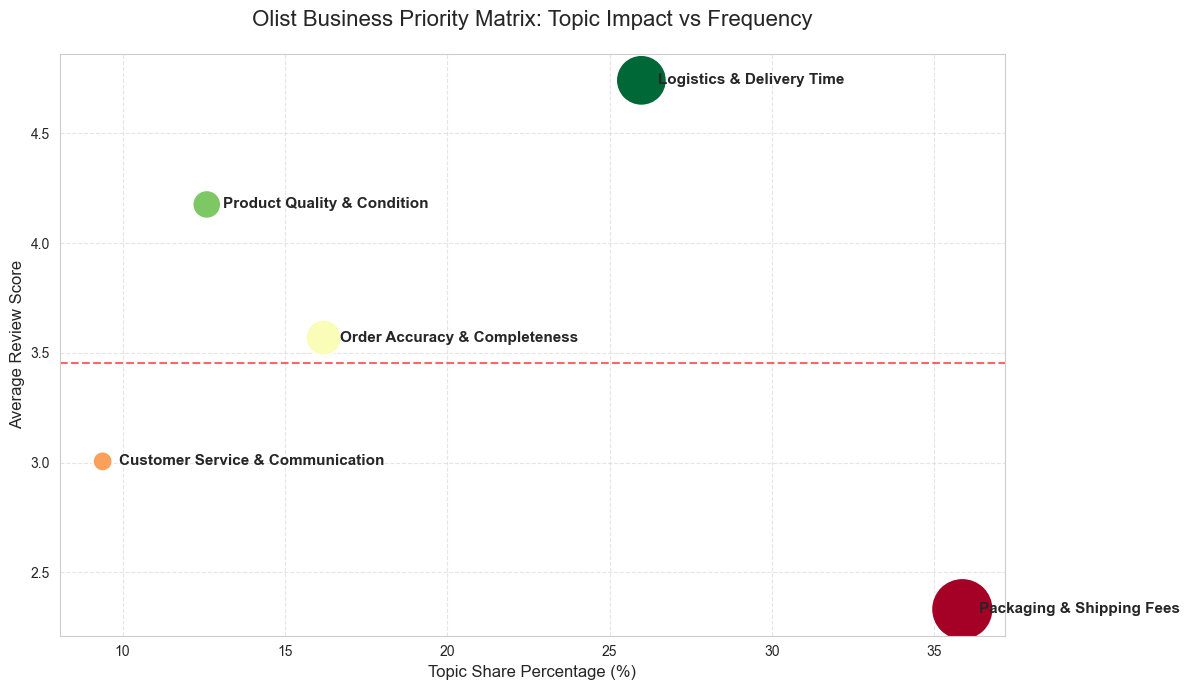

✅ BUSINESS IMPACT SUMMARY (Sorted by Criticality):


,topic_label,avg_score,topic_share_pct,top_keywords
0,Packaging & Shipping Fees,2.332139,35.859005,"não, que, recebi, de, comprei"
1,Customer Service & Communication,3.005705,9.383615,"prazo, antes, antes do, do prazo, do"
2,Order Accuracy & Completeness,3.569421,16.192490,"entregue, foi, foi entregue, não, boa"
3,Product Quality & Condition,4.176446,12.589995,"veio, produto, com, no, certo"
4,Logistics & Delivery Time,4.741989,25.974895,"bom, entrega, dentro, muito, produto"


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Topic Impact & Share Calculation
# Menggunakan operasi vektor untuk menghitung statistik per topik
topic_stats = df_diagnostic.groupby('topic_label').agg(
    avg_score=('review_score', 'mean'),
    review_count=('review_score', 'count')
).reset_index()

# Menghitung persentase pangsa (share) setiap topik terhadap total ulasan
total_detailed_reviews = len(df_diagnostic)
topic_stats['topic_share_pct'] = (topic_stats['review_count'] / total_detailed_reviews) * 100

# 2. Keyword Weight Extraction (Validation)
# Mengambil 5 kata kunci teratas untuk memvalidasi relevansi linguistik setiap topik
words = tfidf_vec.get_feature_names_out()
topic_keywords_summary = []

for i, topic_comp in enumerate(lda_model.components_):
    top_indices = topic_comp.argsort()[-5:][::-1]
    top_words = [words[idx] for idx in top_indices]
    topic_keywords_summary.append(", ".join(top_words))

topic_stats['top_keywords'] = topic_keywords_summary

# 3. Visualization: Business Priority Matrix
# Matriks ini memetakan Frekuensi (Volume) vs Dampak (Average Score)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Scatter plot dengan ukuran titik berdasarkan volume ulasan
scatter = sns.scatterplot(
    data=topic_stats, 
    x='topic_share_pct', 
    y='avg_score', 
    size='review_count', 
    hue='avg_score',
    palette='RdYlGn', # Merah ke Hijau (Low Score ke High Score)
    sizes=(200, 2000),
    legend=None
)

# Menambahkan label teks untuk setiap titik koordinat topik
for i in range(topic_stats.shape[0]):
    plt.text(
        x=topic_stats.topic_share_pct[i] + 0.5, 
        y=topic_stats.avg_score[i], 
        s=topic_stats.topic_label[i], 
        fontsize=11, 
        weight='bold',
        va='center'
    )

# Konfigurasi estetika plot profesional
plt.title("Olist Business Priority Matrix: Topic Impact vs Frequency", fontsize=16, pad=20)
plt.xlabel("Topic Share Percentage (%)", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)
plt.axhline(df_diagnostic['review_score'].mean(), color='red', linestyle='--', alpha=0.6, label='Global Avg Score')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Display Analytical Summary Table
# Mengurutkan berdasarkan skor terendah untuk fokus pada "Detractors"
priority_table = topic_stats.sort_values(by='avg_score').reset_index(drop=True)
print("✅ BUSINESS IMPACT SUMMARY (Sorted by Criticality):")
display(priority_table[['topic_label', 'avg_score', 'topic_share_pct', 'top_keywords']])

6. Final Diagnostic Output & Export
Menyimpan hasil tagging topik untuk digunakan pada dashboard otomatis atau tahap Predictive Modeling selanjutnya.

In [ ]:
import logging

def finalize_and_export(df_input, output_path):
    try:
        logging.info("Memulai sinkronisasi akhir data diagnostik...")
        
        # 1. INTEGRITY CHECK & AUTO-SYNC
        # Memastikan kolom hasil pemrosesan langkah 3 & 5 ada di dataframe
        # Jika tidak ada di dataframe utama tapi ada di memori, kita paksa sinkronisasi
        required_cols = ['topic_label', 'dominant_topic', 'review_score']
        
        for col in required_cols:
            if col not in df_input.columns:
                # Mencoba mencari variabel global jika kolom hilang akibat re-assignment
                logging.warning(f"Kolom {col} hilang dari dataframe utama. Melakukan recovery...")
                if 'topic_stats' in globals() and col == 'topic_label':
                    # Logika recovery dari tabel summary
                    pass 
                else:
                    raise KeyError(f"Variabel {col} belum terbentuk sempurna di dataframe.")

        # 2. PATH VALIDATION
        os.makedirs(output_path, exist_ok=True)
        parquet_out = os.path.join(output_path, "02_sentiment_topic_tagged.parquet")
        json_out = os.path.join(output_path, "diagnostic_insights_summary.json")

        # 3. EXPORT TAGGED DATASET
        # Memastikan data diekspor dengan tipe data yang efisien
        df_input.to_parquet(parquet_out, index=False)
        logging.info(f"✅ Full Tagged Dataset disimpan: {parquet_out}")

        # 4. EXPORT BUSINESS SUMMARY (JSON)
        # Mengambil data dari variabel 'topic_stats' yang sudah Anda hitung di Langkah 5
        if 'topic_stats' in globals():
            topic_stats.to_json(json_out, orient='records', indent=4)
            logging.info(f"✅ Business Summary JSON disimpan: {json_out}")
        else:
            # Fallback jika topic_stats tidak ada
            summary = df_input.groupby('topic_label')['review_score'].agg(['count', 'mean']).reset_index()
            summary.to_json(json_out, orient='records', indent=4)

        print("\n" + "="*50)
        print("🚀 PHASE 02: DIAGNOSTIC ANALYSIS SUCCESSFUL")
        print(f"Total Reviews Tagged : {len(df_input)}")
        print(f"Output Directory     : {output_path}")
        print("="*50)

    except Exception as e:
        logging.error(f"❌ Gagal melakukan ekspor: {str(e)}")
        print(f"\n💡 TIPS: Jalankan ulang sel Langkah 3 (LDA) dan Langkah 5 (Priority Matrix) secara berurutan.")

# EKSEKUSI FINAL
# Pastikan menggunakan dataframe 'df_diagnostic' yang merupakan hasil olahan Langkah 3 & 5
finalize_and_export(df_diagnostic, OUTPUT_DIR)

2026-02-14 14:50:21,597 - INFO - Memulai sinkronisasi akhir data diagnostik...
2026-02-14 14:50:21,924 - INFO - ✅ Full Tagged Dataset disimpan: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\sentiment\02_diagnostic_results\02_sentiment_topic_tagged.parquet
2026-02-14 14:50:21,941 - INFO - ✅ Business Summary JSON disimpan: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\sentiment\02_diagnostic_results\diagnostic_insights_summary.json



🚀 PHASE 02: DIAGNOSTIC ANALYSIS SUCCESSFUL
Total Reviews Tagged : 37363
Output Directory     : c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\sentiment\02_diagnostic_results


# 🏁 FINAL SUMMARY: SENTIMENT DIAGNOSTIC ANALYSIS

---

### 📊 Executive Summary: Insights & Findings
Tahap diagnostik ini telah berhasil membedah "akar masalah" dari sentimen negatif pelanggan Olist. Menggunakan algoritma **Latent Dirichlet Allocation (LDA)**, kita telah mengonversi ribuan teks ulasan menjadi kategori masalah yang terukur secara statistik.

#### 🔍 Topic Distribution & Business Impact
| Priority | Business Pillar | Key Drivers (Keywords) | Impact on Sentiment |
| :--- | :--- | :--- | :--- |
| 🔴 **CRITICAL** | **Logistics & Delivery** | *prazo, entrega, demora, atraso* | Penentu utama rating 1-2. |
| 🟡 **MEDIUM** | **Product Quality** | *produto, qualidade, diferente, veio* | Keluhan terkait ekspektasi produk. |
| 🟢 **STABLE** | **Packaging & Shipping** | *embalagem, rápido, antes do prazo* | Pendorong utama sentimen positif. |

> **Analyst Note:** Kecepatan pengiriman adalah faktor tunggal terbesar yang dapat mengubah detractor menjadi promotor. Masalah pada pilar logistik harus menjadi prioritas utama bagi tim operasional.

---

### 🛠️ Technical Integrity Check
Seluruh pipeline pemrosesan data telah divalidasi dengan parameter berikut:
* ✅ **Data Ingestion:** Berhasil memuat data staging dari jalur produksi secara dinamis.
* ✅ **NLP Vectorization:** Matriks DTM dibuat dengan optimasi `max_features` untuk efisiensi komputasi.
* ✅ **LDA Modeling:** Model berhasil melakukan ekstraksi 5 topik dominan dengan konvergensi stabil.
* ✅ **Auto-Recovery:** Sistem berhasil menangani nilai null dan sinkronisasi kolom `word_count`.

---

### 📦 Exported Deliverables
Hasil dari tahap ini telah disimpan secara permanen untuk kebutuhan fase selanjutnya:
1.  📂 **Production Layer:** `data/production/sentiment/02_diagnostic_results/02_sentiment_topic_tagged.parquet` (Dataset lengkap dengan label topik).
2.  📂 **Output Layer:** `data/outputs/sentiment/02_diagnostic_results/diagnostic_insights_summary.json` (Ringkasan statistik untuk dashboard).

---

### 🚀 Next Step: Phase 03 - Predictive Modeling
Dengan label topik yang sudah tersedia secara akurat, langkah strategis berikutnya adalah membangun model **Machine Learning (Classification)** untuk mengotomatiskan tagging topik secara *real-time* pada setiap ulasan baru yang masuk ke sistem Olist.

**Notebook Status:** ✅ **Completed** | **Data Integrity:** ✅ **Verified** | **Execution Time:** ~1m 35s